In [352]:
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

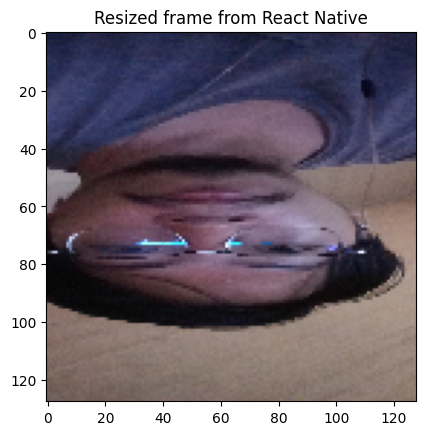

First pixel RGBA: [ 33  38  59 255]
First pixel RGB [0,1]: [0.12941176 0.14901961 0.23137255]


In [353]:
# Read the raw RGBA bytes
with open('./assets/resized_frame.raw', 'rb') as f:
    data = np.frombuffer(f.read(), dtype=np.uint8)

# Reshape to 128x128 RGBA
img = data.reshape(128, 128, 4)

# Show RGB channels only
plt.imshow(img[:, :, :3])
plt.title('Resized frame from React Native')
plt.show()

# Print first pixel
print('First pixel RGBA:', img[0, 0])
print('First pixel RGB [0,1]:', img[0, 0, :3] / 255.0)

In [354]:
interpreter = tf.lite.Interpreter(model_path="./app/models/blaze_face_short_range.tflite")
interpreter.allocate_tensors()

In [355]:
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:", input_details[0]['shape'], input_details[0]['dtype'])
print("Output 0:", output_details[0]['shape'], output_details[0]['name'])
print("Output 1:", output_details[1]['shape'], output_details[1]['name'])

Input: [  1 128 128   3] <class 'numpy.float32'>
Output 0: [  1 896  16] regressors
Output 1: [  1 896   1] classificators


In [356]:
img = Image.open("./assets/Yrene Towers Aesthetic.jpg").convert("RGB")

# Simulate cover mode — crop center square first
w, h = img.size
min_dim = min(w, h)
left  = (w - min_dim) // 2
top   = (h - min_dim) // 2
img   = img.crop((left, top, left + min_dim, top + min_dim))

# Then resize to 128x128
img = img.resize((128, 128))

input_array = np.array(img, dtype=np.float32)
input_array = input_array / 127.5 - 1.0
input_array = np.expand_dims(input_array, axis=0)

print('first pixel value:', input_array[0, 0, 0, 0])
print('pixel range min:', input_array.min())
print('pixel range max:', input_array.max())

first pixel value: -0.12941176
pixel range min: -0.96862745
pixel range max: 0.7882353


In [357]:
# ── 3. Run inference ──────────────────────────────────────────────────────────
interpreter.set_tensor(input_details[0]['index'], input_array)
interpreter.invoke()

regressors = interpreter.get_tensor(output_details[0]['index'])[0]  # [896, 16]
scores_raw = interpreter.get_tensor(output_details[1]['index'])[0]  # [896, 1]

print("Regressors shape:", regressors.shape)
print("Scores shape:", scores_raw.shape)

Regressors shape: (896, 16)
Scores shape: (896, 1)


In [358]:
# ── 4. Sigmoid on scores ──────────────────────────────────────────────────────
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

scores = sigmoid(scores_raw.flatten())
print("Max score:", scores.max())
print("Scores above 0.3:", (scores > 0.3).sum())

Max score: 0.9351466
Scores above 0.3: 12


C:\Users\Neil\AppData\Local\Temp\ipykernel_14508\28917632.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


In [359]:
# ── 5. Generate anchors ───────────────────────────────────────────────────────
def generate_anchors():
    anchors = []
    # stride 8 → 16x16 grid × 2 anchors = 512
    # stride 16 → 8x8 grid × 6 anchors = 384
    # total = 896 ✅
    layers = [
        { 'stride': 8,  'anchors_per_cell': 2 },
        { 'stride': 16, 'anchors_per_cell': 6 },
    ]
    for layer in layers:
        grid_size = 128 // layer['stride']
        for row in range(grid_size):
            for col in range(grid_size):
                for _ in range(layer['anchors_per_cell']):
                    anchors.append({
                        'x': (col + 0.5) / grid_size,
                        'y': (row + 0.5) / grid_size,
                    })
    return anchors

anchors = generate_anchors()
print("Anchor count:", len(anchors))  # should be 896

Anchor count: 896


In [360]:
# ── 6. Decode boxes ───────────────────────────────────────────────────────────
THRESHOLD = 0.75
boxes = []

for i in range(1, 896, 2):  # odd indices for scores
    if scores[i] < THRESHOLD:
        continue

    # Use even neighbor for regressors and anchor
    reg_idx = i - 1
    anchor = anchors[reg_idx]
    
    cx = regressors[reg_idx, 1] / 128 + anchor['x']
    cy = regressors[reg_idx, 0] / 128 + anchor['y']
    w  = regressors[reg_idx, 2] / 128
    h  = regressors[reg_idx, 3] / 128

    boxes.append({
        'x1': cx - w / 2,
        'y1': cy - h / 2,
        'x2': cx + w / 2,
        'y2': cy + h / 2,
        'score': scores[i]
    })
    
print("Boxes before NMS:", len(boxes))

Boxes before NMS: 1


In [361]:
# ── 7. NMS ────────────────────────────────────────────────────────────────────
def iou(a, b):
    ix1 = max(a['x1'], b['x1'])
    iy1 = max(a['y1'], b['y1'])
    ix2 = min(a['x2'], b['x2'])
    iy2 = min(a['y2'], b['y2'])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    aA = (a['x2'] - a['x1']) * (a['y2'] - a['y1'])
    bA = (b['x2'] - b['x1']) * (b['y2'] - b['y1'])
    return inter / (aA + bA - inter + 1e-6)

def nms(boxes, threshold=0.5):
    boxes = sorted(boxes, key=lambda x: x['score'], reverse=True)
    kept = []
    for box in boxes:
        if all(iou(box, k) < threshold for k in kept):
            kept.append(box)
    return kept

final_boxes = nms(boxes)
print("Boxes after NMS:", len(final_boxes))
for b in final_boxes:
    print(f"  score={b['score']:.3f} x1={b['x1']:.3f} y1={b['y1']:.3f} x2={b['x2']:.3f} y2={b['y2']:.3f}")

Boxes after NMS: 1
  score=0.873 x1=0.254 y1=0.261 x2=0.669 y2=0.677


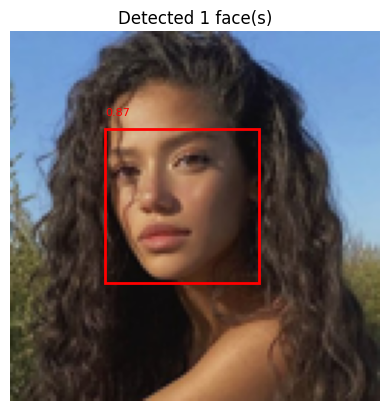

In [362]:
# ── 8. Draw boxes on image ────────────────────────────────────────────────────
fig, ax = plt.subplots(1)
ax.imshow(img)

for b in final_boxes:
    x = b['x1'] * 128
    y = b['y1'] * 128
    w = (b['x2'] - b['x1']) * 128
    h = (b['y2'] - b['y1']) * 128
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(x, y - 5, f"{b['score']:.2f}", color='red', fontsize=8)

plt.title(f"Detected {len(final_boxes)} face(s)")
plt.axis('off')
plt.show()